In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# A notebook to analyze backtesting results

This simple notebook is to be used to 
- visualize the spread between the theoretical price of an option and the price of the corresponding hedging portfolio,
- compute the tracking error for the hedging portfolio.
It takes as an input the json file containing the output data produced by the hedger.

## Set the path to the file to investigate

In [81]:
FILE = 'TestOutputs/Test_1_1.json' #enter correct path here

In [82]:
df = pd.read_json(FILE, convert_dates=['date'])
df.sort_values(by='date', inplace=True)
df.set_index('date', inplace=True)

## Plot the portfolio value against the theoretical price

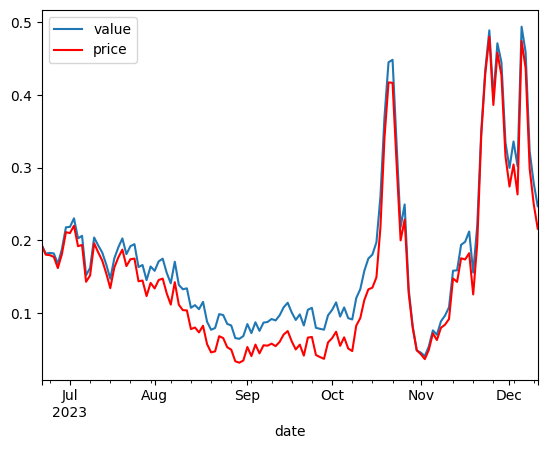

In [83]:
ax = plt.gca()
df.plot(y = 'value', ax = ax)
df.plot(y = 'price', color = 'red', ax = ax)
plt.show()

## Compute the PnL and tracking error

In [80]:
pnl = df['value'].iloc[-1] - df['price'].iloc[-1]
print(f'PnL: {pnl:.2f}')
tracking_error = (df['value'].iloc[-1] - df.price.iloc[-1])/df.price.iloc[0]
print(f'Tracking error: {tracking_error:.2%}')

PnL: 0.02
Tracking error: 1.39%


### Compute the cumulated transaction costs

In [69]:
df.head()

,value,deltas,deltasStdDev,price,priceStdDev,transactionCosts
date,,,,,,
2023-06-22,1.239204,[0.8142774868239481],[0],1.239204,0,0
2023-06-23,1.356854,[0.8413073761341491],[0],1.357379,0,0
2023-06-26,1.325352,[0.835622618080407],[0],1.324566,0,0
2023-06-27,1.304589,[0.832022842001739],[0],1.302403,0,0
2023-06-28,1.175561,[0.8031155746645771],[0],1.174049,0,0


In [13]:
df['total_tc'] = df.transactionCosts.cumsum()

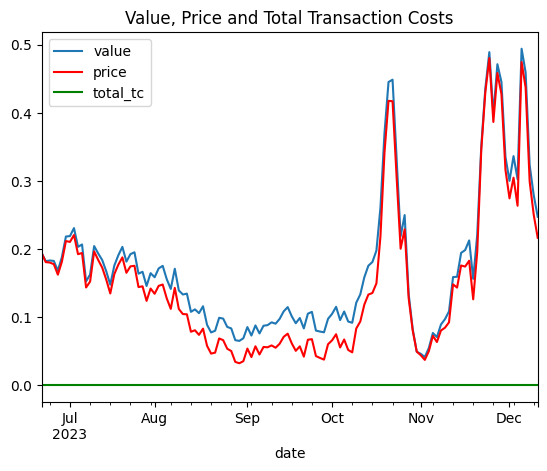

In [14]:
ax = plt.gca()
df.plot(y = 'value', ax = ax)
df.plot(y = 'price', color = 'red', ax = ax)
df.plot(y = 'total_tc', color = 'green', ax = ax)
plt.title('Value, Price and Total Transaction Costs')
plt.show()

In [15]:
total_pnl = df['value'].iloc[-1] - df['price'].iloc[-1] - df['total_tc'].iloc[-1]
print(f'Total PnL after transaction costs: {total_pnl:.2f}')

Total PnL after transaction costs: 0.03
